In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import contextily as cx
import numpy as np

In [7]:
PISTES_FP = "data/vicheres_pistes.geojson"

pistes_gdf = gpd.read_file(PISTES_FP)

In [2]:
run_stats = gpd.read_file("data/processed/run_stats_valid_runs.geojson")

In [3]:
run_stats["piste_length_m"] = run_stats.geometry.length

In [5]:
run_stats.columns

Index(['run_id', 'piste_id', 'start_time', 'end_time', 'distance_m',
       'elev_start', 'elev_end', 'elev_min', 'elev_max', 'n_points',
       'duration_s', 'duration_min', 'distance_km', 'elev_change_m',
       'elev_range_m', '@id', 'highway', 'name', 'piste:difficulty',
       'piste:grooming', 'piste:name', 'piste:type', 'source', 'tracktype',
       'plot_color', 'geometry', 'piste_length_m'],
      dtype='str')

In [11]:
stats

,run_id,piste_id,start_time,end_time,distance_m,elev_start,elev_end,elev_min,elev_max,n_points,...,name,piste:difficulty,piste:grooming,piste:name,piste:type,source,tracktype,plot_color,geometry,piste_length_m
0,0_100,way/52041160,2026-02-26 14:45:24+00:00,2026-02-26 14:46:53+00:00,470.825298,2049.4,2011.0,2011.0,2049.4,33,...,NaN,easy,NaN,NaN,downhill,GPS survey 2010.03.08; mapbox,grade4,blue,"LINESTRING (796001.23 5778018.089, 796009.055 ...",684.551108
1,0_106,way/52041287,2026-02-26 14:53:23+00:00,2026-02-26 15:01:57+00:00,1563.667368,2237.4,1970.1,1970.1,2243.9,125,...,NaN,intermediate,NaN,Six niés,downhill,GPS survey 2010.03.08,NaN,red,"LINESTRING (795364.104 5776476.728, 795376.95 ...",1336.901566
2,0_112,way/52041284,2026-02-26 15:09:24+00:00,2026-02-26 15:10:40+00:00,634.895798,2245.9,2179.9,2179.8,2245.9,50,...,NaN,easy,classic,Le Chameau,downhill,GPS survey 2010.03.08,NaN,blue,"LINESTRING (795364.104 5776476.728, 795362.078...",1696.469858
3,0_114,way/52041284,2026-02-26 15:10:45+00:00,2026-02-26 15:11:44+00:00,348.272109,2178.3,2127.7,2127.7,2178.3,22,...,NaN,easy,classic,Le Chameau,downhill,GPS survey 2010.03.08,NaN,blue,"LINESTRING (795364.104 5776476.728, 795362.078...",1696.469858
4,0_115,way/52041158,2026-02-26 15:11:46+00:00,2026-02-26 15:12:16+00:00,459.831462,2124.2,2028.1,2028.1,2124.2,30,...,NaN,easy,classic,NaN,downhill,GPS survey 2010.03.08,NaN,blue,"LINESTRING (795689.991 5777991.895, 795758.319...",539.227751
5,0_120,way/52041284,2026-02-26 15:23:51+00:00,2026-02-26 15:26:35+00:00,363.676794,2172.1,2119.1,2119.1,2173.1,31,...,NaN,easy,classic,Le Chameau,downhill,GPS survey 2010.03.08,NaN,blue,"LINESTRING (795364.104 5776476.728, 795362.078...",1696.469858
6,0_122,way/52041284,2026-02-26 15:26:38+00:00,2026-02-26 15:28:50+00:00,461.268843,2108.2,2029.5,2029.5,2108.2,34,...,NaN,easy,classic,Le Chameau,downhill,GPS survey 2010.03.08,NaN,blue,"LINESTRING (795364.104 5776476.728, 795362.078...",1696.469858
7,0_126,way/52041284,2026-02-26 15:35:06+00:00,2026-02-26 15:37:47+00:00,333.830030,2171.8,2126.2,2126.2,2173.5,29,...,NaN,easy,classic,Le Chameau,downhill,GPS survey 2010.03.08,NaN,blue,"LINESTRING (795364.104 5776476.728, 795362.078...",1696.469858
8,0_128,way/52041284,2026-02-26 15:37:51+00:00,2026-02-26 15:38:27+00:00,500.048715,2117.2,2026.7,2026.7,2117.2,37,...,NaN,easy,classic,Le Chameau,downhill,GPS survey 2010.03.08,NaN,blue,"LINESTRING (795364.104 5776476.728, 795362.078...",1696.469858
9,0_13,way/52041159,2026-02-26 10:39:01+00:00,2026-02-26 10:42:51+00:00,662.827466,2173.4,2016.7,2016.7,2173.4,52,...,La Combette,intermediate,classic,NaN,downhill,GPS survey 2010.03.08,NaN,red,"LINESTRING (795540.378 5777481.951, 795553.035...",585.599861


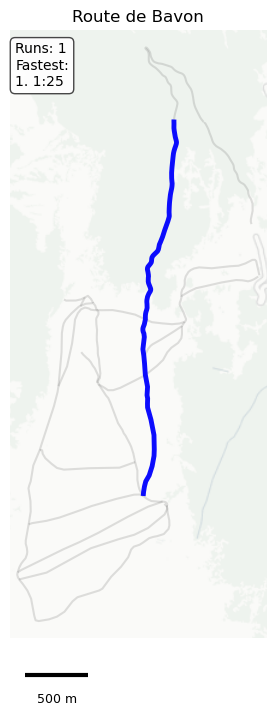

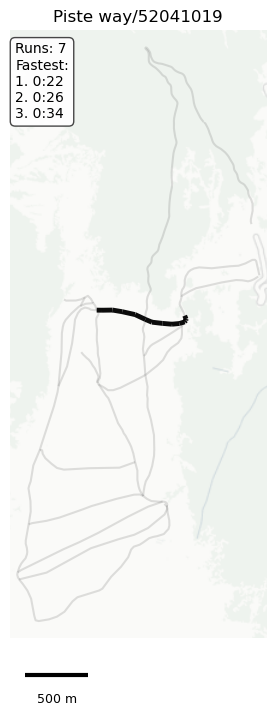

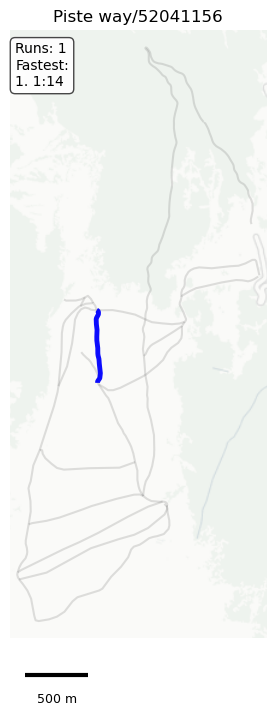

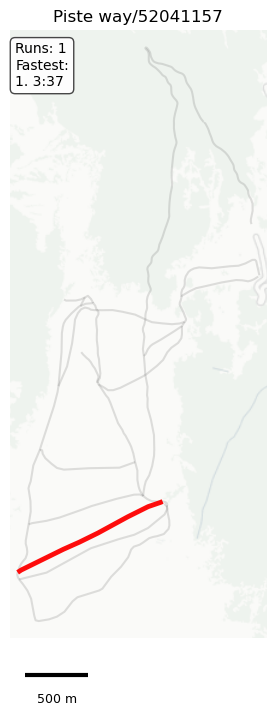

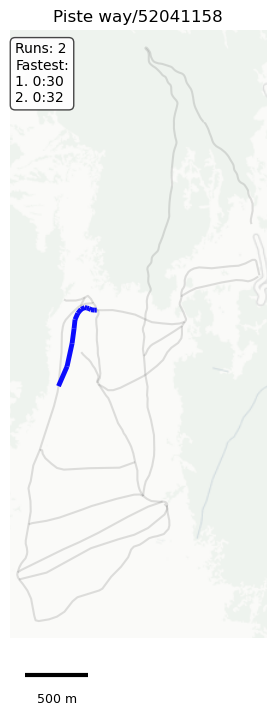

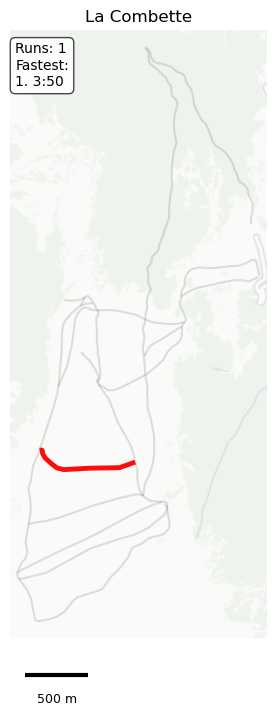

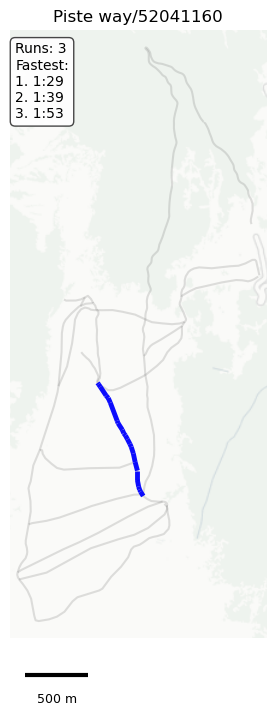

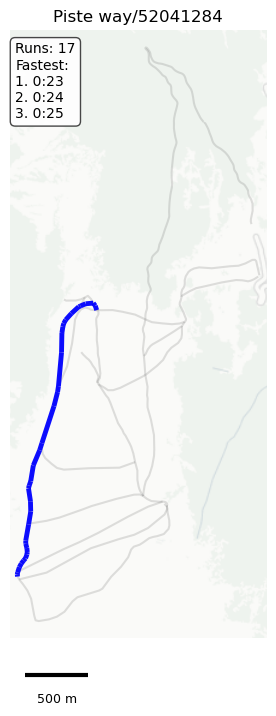

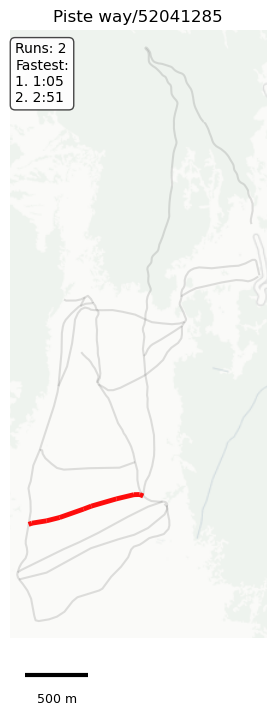

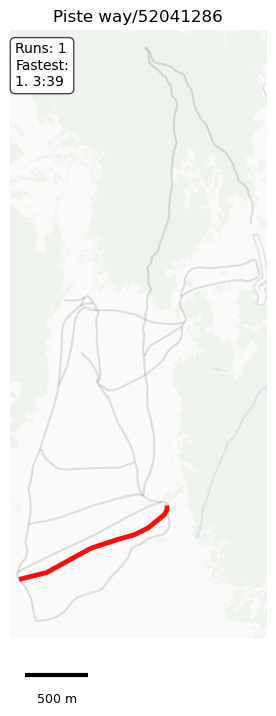

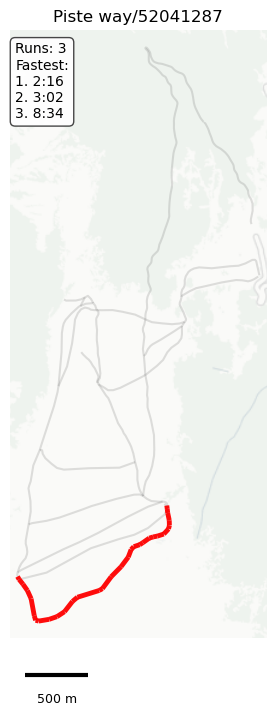

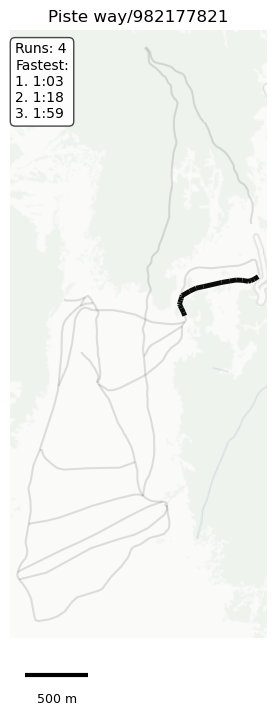

In [18]:
# Inputs:
# - pistes_gdf: all pistes (geometry for full resort)
# - run_stats: per-run stats with at least piste_id, duration_s, name, plot_color, geometry

all_pistes = pistes_gdf.copy()
stats = run_stats.copy()

# 1) Use one CRS for plotting/basemap
if all_pistes.crs.to_epsg() != 3857:
    all_pistes = all_pistes.to_crs(3857)
if stats.crs.to_epsg() != 3857:
    stats = stats.to_crs(3857)

# 2) Pre-download ONE basemap image for full resort extent
minx, miny, maxx, maxy = all_pistes.total_bounds
padx = (maxx - minx) * 0.03
pady = (maxy - miny) * 0.03
extent = (minx - padx, maxx + padx, miny - pady, maxy + pady)

img, ext = cx.bounds2img(
    extent[0], extent[2], extent[1], extent[3],
    source=cx.providers.CartoDB.Positron,
    ll=False,
    zoom=14
)

def fmt_time(sec):
    sec = int(round(sec))
    m, s = divmod(sec, 60)
    h, m = divmod(m, 60)
    return f"{h}:{m:02d}:{s:02d}" if h else f"{m}:{s:02d}"

def add_scalebar_below(ax, frac=0.18):
    # Scale length from map width (meters in EPSG:3857)
    xmin, xmax = ax.get_xlim()
    map_width_m = xmax - xmin
    target = map_width_m * frac
    nice = np.array([50, 100, 200, 500, 1000, 2000, 5000, 10000], dtype=float)
    L = nice[np.argmin(np.abs(nice - target))]

    # Convert to axes fraction for drawing in axes coordinates
    L_ax = L / map_width_m

    # Below plot (y < 0), left aligned
    x0_ax = 0.06
    y0_ax = -0.06
    ax.plot(
        [x0_ax, x0_ax + L_ax], [y0_ax, y0_ax],
        transform=ax.transAxes, color="black", lw=3, solid_capstyle="butt",
        clip_on=False, zorder=20
    )

    label = f"{int(L/1000)} km" if L >= 1000 else f"{int(L)} m"
    ax.text(
        x0_ax + L_ax / 2, y0_ax - 0.03, label,
        transform=ax.transAxes, ha="center", va="top",
        fontsize=9, color="black", clip_on=False, zorder=20
    )

for piste_id, g in stats.groupby("piste_id", dropna=True):
    if g.empty:
        continue

    top3 = g.nsmallest(3, "duration_s")["duration_s"].tolist()
    times_txt = "\n".join(f"{i+1}. {fmt_time(t)}" for i, t in enumerate(top3))
    run_count = len(g)

    name = g["name"].dropna().iloc[0] if g["name"].notna().any() else f"Piste {piste_id}"
    color = g["plot_color"].dropna().iloc[0] if g["plot_color"].notna().any() else "#1f77b4"

    # Single highlighted geometry for this piste
    highlight_geom = g.geometry.union_all()
    highlight = gpd.GeoSeries([highlight_geom], crs=stats.crs)

    fig, ax = plt.subplots(figsize=(8, 8))

    # same cached basemap for every plot
    ax.imshow(img, extent=ext, interpolation="bilinear", zorder=0)

    # all pistes, muted
    all_pistes.plot(ax=ax, color="#666666", linewidth=1.5, alpha=0.20, zorder=2)

    # current piste, prominent
    highlight.plot(ax=ax, color=color, linewidth=3.5, alpha=0.95, zorder=3)

    # fixed full-resort extent
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect("equal")

    # Title: just piste name
    ax.set_title(name, fontsize=12)

    # Stats box in top-left
    info_txt = f"Runs: {run_count}\nFastest:\n{times_txt if times_txt else 'No runs'}"
    ax.text(
        0.02, 0.98, info_txt,
        transform=ax.transAxes, ha="left", va="top", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#333333", alpha=0.9),
        zorder=30
    )

    # Scale bar below plot
    add_scalebar_below(ax)

    ax.set_axis_off()
    fig.subplots_adjust(bottom=0.12)  # room for scale bar below axes
    plt.show()
